# 22. 시장 패널 EDA: 지역 축이 살아 있는가

## Overview

**새 트랙을 엽니다.** 01~09 는 예측, 10~21 은 이해였고, 여기부터는 **통계·인과**
입니다. 예측 트랙은 21번에서 닫았습니다: 모델 구조·피처로 더 짜낼 게 없습니다.

방향을 바꾼 계기는 `mafra` 계약재배 조회였습니다. DiD 재료로 쓰려 했는데
**시점이 2개(2024-06·2025-11)뿐이고 처치 시점이 없어** 성립하지 않았습니다.
대신 다른 게 보였습니다.

## 마트가 버린 축을 되찾습니다

지금까지 쓴 `mart_item_daily` 는 **'날짜 × 표준품목'** 그레인입니다. 그 뒤에
있는 원천 `kamis_wholesale_obs` 에는 **`region` 과 `market` 이 그대로 남아
있습니다.** 마트를 만들면서 집계해 없앤 축입니다.

| | 마트 | 원천 |
|---|---|---|
| 행 수 | 24,078 | **181,503** |
| 그레인 | 날짜 × 품목 | 날짜 × 품목 × 시장 × 품종 |
| 지역 축 | 없음 | **시장 8 · 지역 5** |

**그룹 축이 생기면 인과 설계가 가능해집니다.** 같은 품목·같은 날인데 시장마다
가격이 다르다면, 어떤 사건이 특정 시장에만 걸렸을 때 나머지를 대조군으로
쓸 수 있습니다.

**다만 그건 아직 가정입니다.** 이 문서는 그 가정이 설 자리가 있는지만 봅니다.

## 무엇을 확인하는가

DiD 같은 설계가 성립하려면 최소 세 가지가 필요합니다.

| 필요한 것 | 없으면 |
|---|---|
| **시장 간 가격차가 실재** | 비교할 게 없습니다 |
| **그 차이가 시간에 따라 안정** | 평행추세 가정이 깨집니다 |
| **가격차가 상품 구성 차이가 아님** | 시장 효과가 아니라 품종·규격 차이를 재게 됩니다 |

셋째가 가장 위험합니다: 같은 "배추"라도 시장마다 다른 품종·규격이 올라오면,
가격차는 시장 효과가 아니라 **다른 물건을 비교한 결과**입니다.

## 목차

1. 한 행이 무엇인가
2. 무엇이 빠져 있나 (미거래·결측)
3. 시장 간 가격차가 실재하는가
4. 그 차이가 시간에 따라 안정적인가
5. 가격차가 상품 구성 차이는 아닌가
6. 정리

## 1. 한 행이 무엇인가

먼저 확인합니다: 한 행은 **하루 · 한 품목 · 한 시장 · 한 품종**의 관측입니다.
단위가 섞여 있으면 여기서부터 조용히 틀리므로 그것부터 봅니다.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import font_manager

_av = {f.name for f in font_manager.fontManager.ttflist}
for _f in ("AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"):
    if _f in _av:
        plt.rcParams["font.family"] = _f
        break
sns.set_style("whitegrid", {"font.family": plt.rcParams["font.family"]})
plt.rcParams["axes.unicode_minus"] = False

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
CACHE = ROOT / "notebooks" / ".cache" / "wholesale_obs.parquet"
# 캐시가 없으면 아래 쿼리로 다시 받는다(마트가 아니라 원천이다):
#   SELECT price_date, item, variety, region, market, price, unit_price,
#          unit_qty, unit_base, no_trade, kindname_raw
#   FROM `agriquant.agriculture_data.kamis_wholesale_obs`
#   ORDER BY item, market, price_date
obs = pd.read_parquet(CACHE)
obs["price_date"] = pd.to_datetime(obs["price_date"])

print(f"{len(obs):,}행 | {obs.price_date.min():%Y-%m-%d} ~ {obs.price_date.max():%Y-%m-%d}")
print(f"품목 {obs.item.nunique()} · 시장 {obs.market.nunique()} · 지역 {obs.region.nunique()}"
      f" · 품종 {obs.variety.nunique()}")

print("\n단위(unit_base)")
print(obs.unit_base.value_counts(dropna=False).to_string())

키 = ["price_date", "item", "market", "variety"]
print(f"\n키 {키} 중복: {obs.duplicated(키).sum():,}행")
키2 = 키 + ["unit_qty"]
print(f"규격(unit_qty)까지 넣으면: {obs.duplicated(키2).sum():,}행")
display(obs.head(3))

181,503행 | 2021-01-04 ~ 2026-08-07
품목 19 · 시장 8 · 지역 5 · 품종 24

단위(unit_base)
unit_base
kg    181503

키 ['price_date', 'item', 'market', 'variety'] 중복: 7,099행
규격(unit_qty)까지 넣으면: 7,099행


,price_date,item,variety,region,market,price,unit_price,unit_qty,unit_base,no_trade,kindname_raw
0,2021-01-04,감자,대지마,서울,가락도매,30000.0,1500.0,20.0,kg,False,대지마(20kg)
1,2021-01-04,감자,수미,서울,가락도매,32000.0,1600.0,20.0,kg,False,수미(노지)(20kg)
2,2021-01-05,감자,수미,서울,가락도매,32000.0,1600.0,20.0,kg,False,수미(노지)(20kg)


### 중복이 무엇인지 먼저 봅니다

날짜·품목·시장·품종이 같은데 행이 둘인 경우가 있습니다. **규격이 다른 것인지
진짜 중복인지** 확인해야 그레인이 잡힙니다. 여기를 뭉개면 뒤의 평균이 전부
가중치가 틀린 값이 됩니다.

In [2]:
dup = obs[obs.duplicated(키, keep=False)].sort_values(키)
print(f"중복에 걸린 행 {len(dup):,}개")
print("\n중복 안에서 무엇이 다른가")
for c in ("unit_qty", "unit_raw" if "unit_raw" in obs.columns else "kindname_raw",
          "price", "kindname_raw"):
    if c not in obs.columns:
        continue
    n = dup.groupby(키)[c].nunique()
    print(f"  {c:14s} 값이 2개 이상인 조합: {(n > 1).sum():,} / {len(n):,}")

print("\n실제 사례")
샘플키 = dup.groupby(키).size().sort_values(ascending=False).index[0]
display(dup.set_index(키).loc[[샘플키]].reset_index())

중복에 걸린 행 14,198개

중복 안에서 무엇이 다른가
  unit_qty       값이 2개 이상인 조합: 0 / 7,099
  kindname_raw   값이 2개 이상인 조합: 7,099 / 7,099
  price          값이 2개 이상인 조합: 2,212 / 7,099
  kindname_raw   값이 2개 이상인 조합: 7,099 / 7,099

실제 사례


,price_date,item,market,variety,region,price,unit_price,unit_qty,unit_base,no_trade,kindname_raw
0,2021-01-04,깐마늘(국산),가락도매,깐마늘,서울,135000.0,6750.0,20.0,kg,False,깐마늘(대서)(20kg)
1,2021-01-04,깐마늘(국산),가락도매,깐마늘,서울,135000.0,6750.0,20.0,kg,False,깐마늘(남도)(20kg)


In [3]:
지역시장 = (obs.groupby(["region", "market"])
            .agg(행수=("price", "size"),
                 품목수=("item", "nunique"),
                 일수=("price_date", "nunique"),
                 미거래율=("no_trade", lambda s: s.mean() * 100))
            .sort_values("행수", ascending=False))
display(지역시장.round(1))
print("지역 하나에 주력 시장 하나가 대응합니다: 5대 도매시장이 곧 5개 지역입니다.")
print("아래 셋은 품목이 하나거나 미거래가 99% 라 패널에서 뺍니다.")

행수  품목수    일수  미거래율
region market                        
서울     가락도매    37530   19  1373  31.0
대전     오정도매    35069   18  1373  32.2
광주     서부도매    34913   19  1373  31.4
대구     북부도매    34378   19  1373  29.5
부산     엄궁도매    34088   18  1373  30.1
       남포동건어물   4598   18   242  99.6
대전     역전        648    1   648  16.5
부산     부전        279    1   279   2.2

지역 하나에 주력 시장 하나가 대응합니다: 5대 도매시장이 곧 5개 지역입니다.
아래 셋은 품목이 하나거나 미거래가 99% 라 패널에서 뺍니다.


## 2. 무엇이 빠져 있나

**미거래(`no_trade`)가 32.5% 입니다.** 마트의 `v_price_daily` 는 이 행을 제외하고
있습니다: 넣으면 가격이 아니라 '거래 여부'를 재게 되기 때문입니다.

여기서 중요한 건 **미거래가 시장마다 다르게 발생하는가**입니다. 특정 시장에서만
자주 비면, 그 시장의 평균 가격은 **거래가 성사된 날만 모은 값**이라 다른 시장과
같은 뜻이 아닙니다. 선택 편의입니다.

In [4]:
MAIN = ["가락도매", "오정도매", "서부도매", "북부도매", "엄궁도매"]
p = obs[obs.market.isin(MAIN)].copy()
print(f"주력 5시장만: {len(p):,}행 ({len(p)/len(obs)*100:.1f}%)")

piv = (p.groupby(["item", "market"]).no_trade.mean().unstack() * 100)
piv = piv.astype(float)
piv["편차(최대-최소)"] = piv.max(axis=1) - piv.min(axis=1)
display(piv.round(1).sort_values("편차(최대-최소)", ascending=False))
print("'편차' 가 크면 그 품목은 시장마다 거래 성사 빈도가 달라 비교가 위험합니다.")

주력 5시장만: 175,978행 (97.0%)


market,가락도매,북부도매,서부도매,엄궁도매,오정도매,편차(최대-최소)
item,,,,,,
피마늘,15.4,7.3,26.7,NaN,NaN,19.4
풋고추,0.0,0.0,17.1,0.0,6.9,17.1
감자,44.1,38.3,42.3,41.4,49.8,11.5
깐마늘(국산),47.5,48.6,52.5,48.5,55.1,7.5
미나리,0.0,6.6,0.0,6.1,0.1,6.6
브로콜리,0.0,2.8,1.8,3.4,5.9,5.9
배추,72.8,72.5,72.8,72.8,73.7,1.2
무,71.4,71.9,71.9,71.2,71.6,0.7
양파,0.5,0.1,0.8,0.4,0.7,0.7


'편차' 가 크면 그 품목은 시장마다 거래 성사 빈도가 달라 비교가 위험합니다.


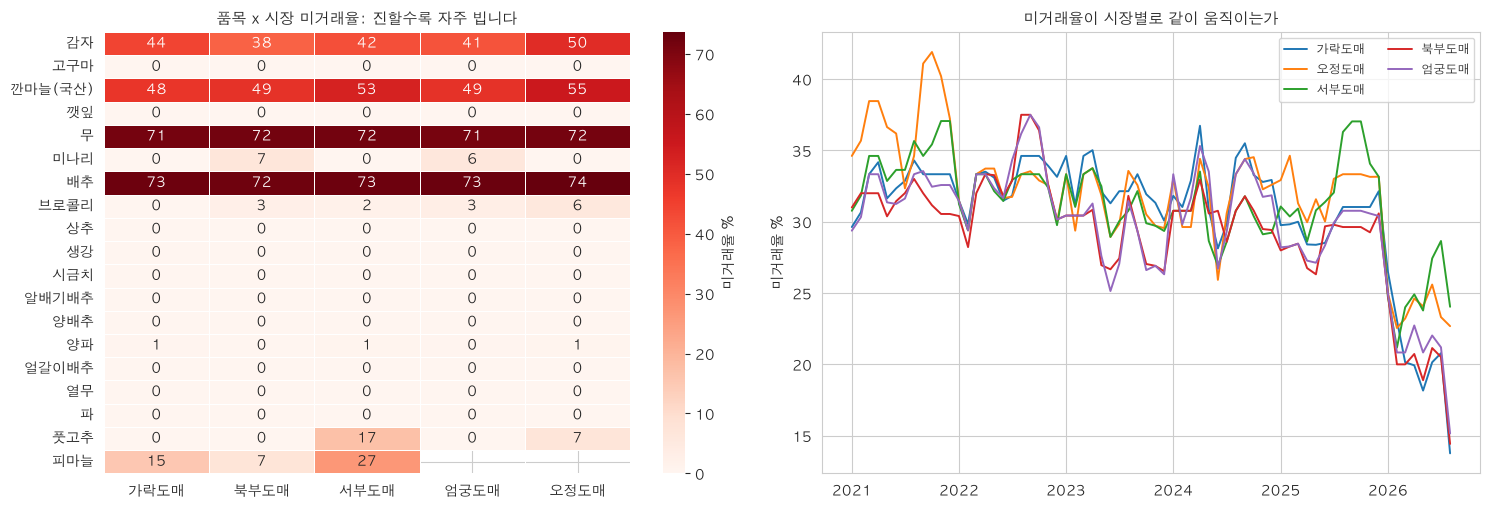

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

ax = axes[0]
sns.heatmap(piv.drop(columns="편차(최대-최소)").astype(float), annot=True, fmt=".0f",
            cmap="Reds", ax=ax, cbar_kws={"label": "미거래율 %"}, linewidths=0.4)
ax.set_title("품목 x 시장 미거래율: 진할수록 자주 빕니다", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("")

ax = axes[1]
월별 = (p.assign(월=p.price_date.dt.to_period("M").dt.to_timestamp())
         .groupby(["월", "market"]).no_trade.mean().unstack() * 100)
for m in MAIN:
    ax.plot(월별.index, 월별[m], lw=1.4, label=m)
ax.set_xlabel("")
ax.set_ylabel("미거래율 %")
ax.set_title("미거래율이 시장별로 같이 움직이는가", fontsize=11)
ax.legend(fontsize=8.5, ncol=2)

plt.tight_layout()
plt.show()

## 3. 시장 간 가격차가 실재하는가

미거래를 빼고 **거래가 성사된 행만** 남겨 봅니다. 같은 품목·같은 날인데 시장마다
가격이 얼마나 다른지가 이 절의 질문입니다.

차이가 없으면 이 축으로는 아무것도 못 합니다.

In [6]:
t = p[(~p.no_trade.fillna(False)) & p.price.notna() & (p.price > 0)].copy()
t["_logp"] = np.log(t.price)
print(f"거래 성사 행 {len(t):,}개 ({len(t)/len(p)*100:.1f}%)")

# 같은 날 같은 품목에서 시장 간 가격이 얼마나 벌어지는가
일별 = (t.groupby(["item", "price_date"])
         .agg(시장수=("market", "nunique"),
              최대=("price", "max"), 최소=("price", "min"),
              평균=("price", "mean"), 로그표준편차=("_logp", "std")))
일별 = 일별[일별.시장수 >= 4]          # 최소 4개 시장이 같이 있는 날만
일별["최대최소비"] = 일별.최대 / 일별.최소

품목별 = (일별.groupby("item")
           .agg(관측일=("시장수", "size"),
                평균_최대최소비=("최대최소비", "mean"),
                중앙_최대최소비=("최대최소비", "median"),
                로그표준편차=("로그표준편차", "mean")))
display(품목별.round(3).sort_values("평균_최대최소비", ascending=False))
print("최대최소비 1.0 이면 시장 간 가격이 같다는 뜻입니다.")
print("로그표준편차는 시장 간 흩어짐이며, 0.10 이면 대략 +-10% 입니다.")

거래 성사 행 121,693개 (69.2%)


,관측일,평균_최대최소비,중앙_최대최소비,로그표준편차
item,,,,
열무,1372,1.590,1.500,0.171
풋고추,1326,1.485,1.397,0.156
미나리,1295,1.442,1.337,0.138
시금치,1372,1.414,1.357,0.132
얼갈이배추,1372,1.399,1.314,0.126
알배기배추,776,1.395,1.350,0.128
브로콜리,693,1.347,1.281,0.115
상추,1372,1.342,1.291,0.113
배추,1371,1.324,1.253,0.103


최대최소비 1.0 이면 시장 간 가격이 같다는 뜻입니다.
로그표준편차는 시장 간 흩어짐이며, 0.10 이면 대략 +-10% 입니다.


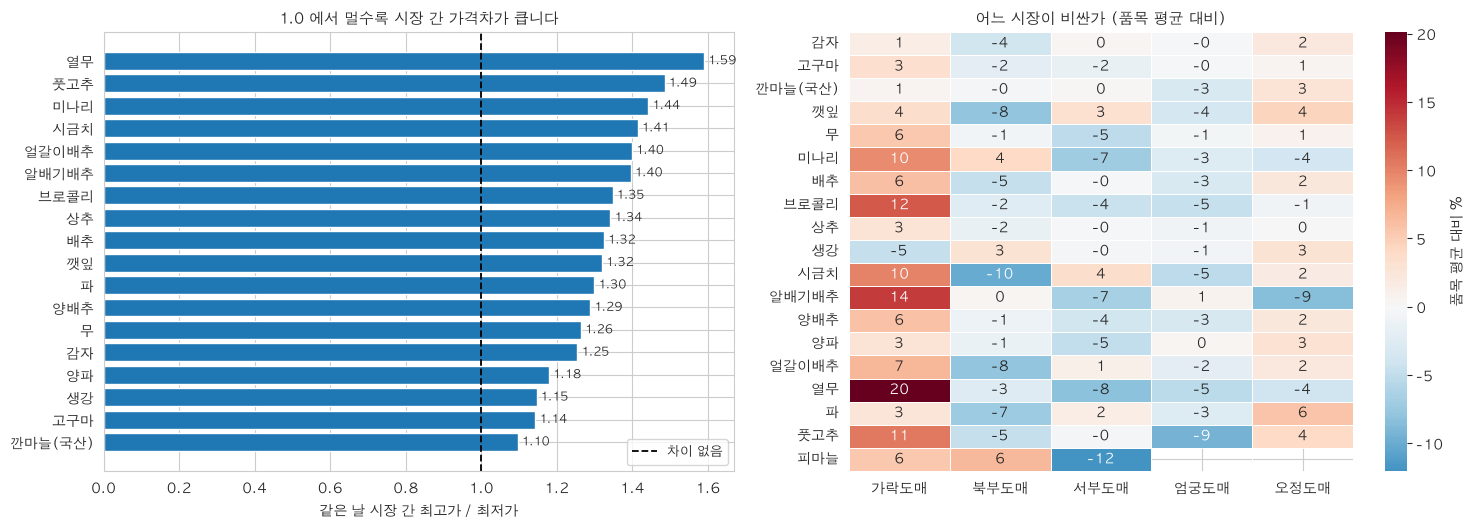

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.4))

ax = axes[0]
s = 품목별.sort_values("평균_최대최소비")
ax.barh(s.index, s.평균_최대최소비, color="tab:blue")
ax.axvline(1.0, color="black", ls="--", lw=1.3, label="차이 없음")
for i, v in enumerate(s.평균_최대최소비):
    ax.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=8.5)
ax.set_xlabel("같은 날 시장 간 최고가 / 최저가")
ax.set_title("1.0 에서 멀수록 시장 간 가격차가 큽니다", fontsize=11)
ax.legend(fontsize=9)

ax = axes[1]
시장평균 = (t.groupby(["item", "market"])._logp.mean().unstack())
상대 = (시장평균.sub(시장평균.mean(axis=1), axis=0)).mul(100)
sns.heatmap(상대, annot=True, fmt=".0f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "품목 평균 대비 %"}, linewidths=0.4)
ax.set_title("어느 시장이 비싼가 (품목 평균 대비)", fontsize=11)
ax.set_xlabel("")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

## 4. 그 차이가 시간에 따라 안정적인가

DiD 의 핵심 가정이 **평행추세**입니다. 처치가 없었다면 두 집단이 같은 방향으로
움직였을 것이라는 가정인데, 검증할 수는 없고 **과거에 나란히 움직였는지**로
가늠합니다.

여기서는 **시장 간 로그가격 차이**가 시간에 따라 일정한지를 봅니다. 일정하면
평행추세가 설 자리가 있고, 계속 벌어졌다 좁아졌다 하면 어렵습니다.

In [8]:
월 = (t.assign(월=t.price_date.dt.to_period("M").dt.to_timestamp())
       .groupby(["item", "월", "market"])._logp.mean().reset_index())
기준 = "가락도매"
w = 월.pivot_table(index=["item", "월"], columns="market", values="_logp")
격차 = w.sub(w[기준], axis=0).drop(columns=[기준]).dropna(how="all")

요약 = pd.DataFrame({
    "평균 격차": 격차.groupby(level="item").mean().mean(axis=1),
    "격차의 시간 변동(표준편차)": 격차.groupby(level="item").std().mean(axis=1),
    "관측 월수": 격차.groupby(level="item").size(),
})
요약["안정성"] = 요약["평균 격차"].abs() / 요약["격차의 시간 변동(표준편차)"]
display(요약.round(3).sort_values("안정성", ascending=False))
print("'안정성' 은 평균 격차를 그 격차의 흔들림으로 나눈 값입니다.")
print("1 보다 크면 격차가 흔들림보다 뚜렷하다는 뜻이라 평행추세를 기대할 만합니다.")

,평균 격차,격차의 시간 변동(표준편차),관측 월수,안정성
item,,,,
알배기배추,-0.175,0.083,39,2.115
열무,-0.254,0.190,68,1.341
브로콜리,-0.162,0.162,39,0.999
시금치,-0.125,0.133,68,0.946
생강,0.061,0.066,68,0.918
무,-0.064,0.079,68,0.817
풋고추,-0.135,0.183,68,0.737
미나리,-0.115,0.161,68,0.717
배추,-0.072,0.128,68,0.561


'안정성' 은 평균 격차를 그 격차의 흔들림으로 나눈 값입니다.
1 보다 크면 격차가 흔들림보다 뚜렷하다는 뜻이라 평행추세를 기대할 만합니다.


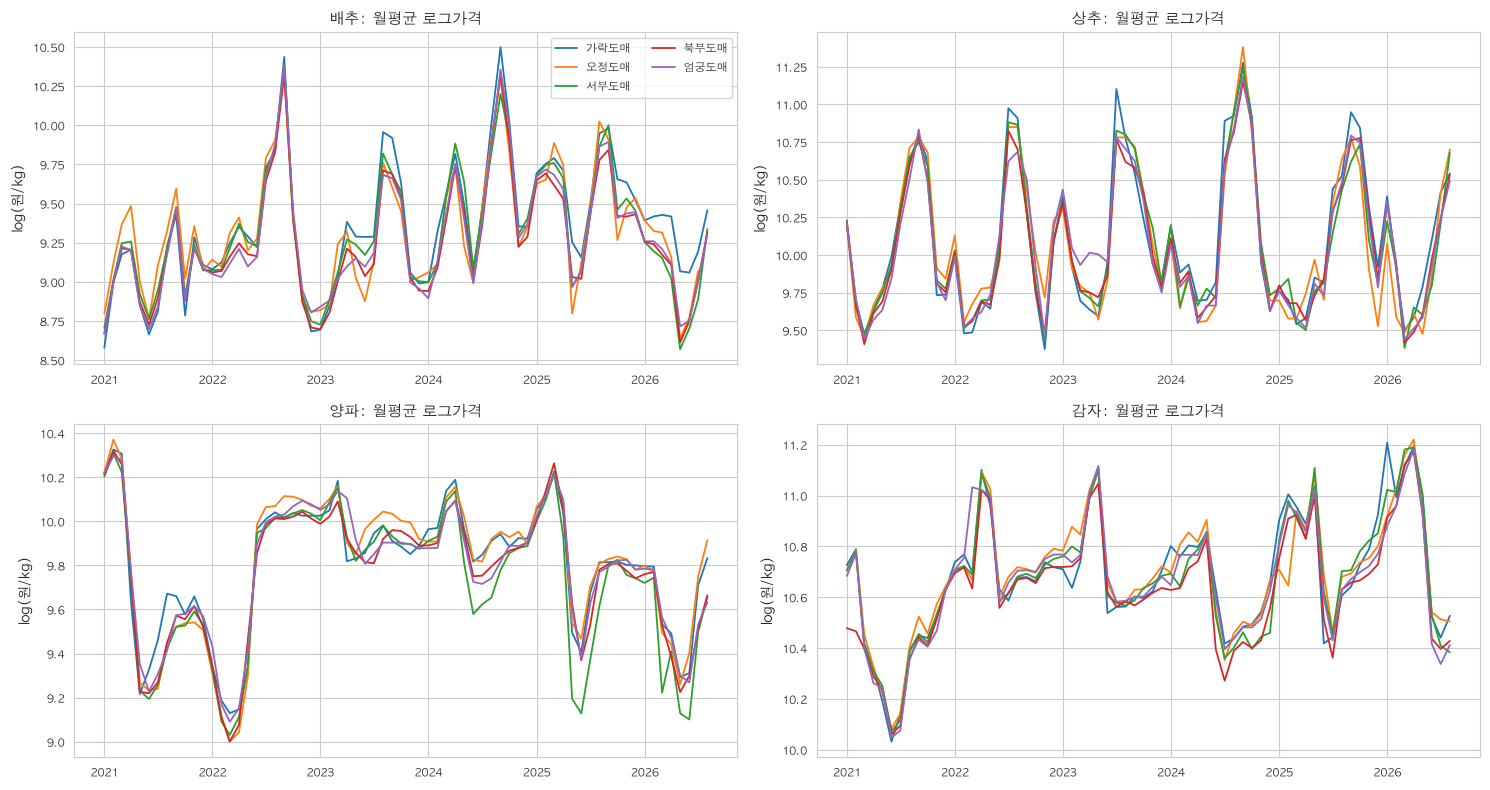

선들이 나란히 오르내리면 평행추세가 설 자리가 있습니다.
한 선만 따로 놀면 그 시장에 뭔가 있었다는 뜻이라, 그게 곧 사건 후보입니다.


In [9]:
보기 = ["배추", "상추", "양파", "감자"]
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, it in zip(axes.ravel(), 보기):
    sub = 월[월.item == it]
    for m in MAIN:
        s = sub[sub.market == m]
        if len(s):
            ax.plot(s.월, s._logp, lw=1.3, label=m)
    ax.set_title(f"{it}: 월평균 로그가격", fontsize=11)
    ax.set_ylabel("log(원/kg)")
    ax.tick_params(labelsize=8)
axes[0, 0].legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()
print("선들이 나란히 오르내리면 평행추세가 설 자리가 있습니다.")
print("한 선만 따로 놀면 그 시장에 뭔가 있었다는 뜻이라, 그게 곧 사건 후보입니다.")

## 5. 가격차가 상품 구성 차이는 아닌가

**여기가 가장 위험한 지점입니다.** 같은 "배추"라도 시장마다 다른 품종·규격이
올라오면, 앞에서 본 가격차는 시장 효과가 아니라 **다른 물건을 비교한 결과**
입니다.

1절에서 **진짜 그레인이 `kindname_raw`** 임을 확인했으니(`variety` 가 같아도
`kindname_raw` 가 다른 행이 7,099 조합), 그 기준으로 봅니다.

In [10]:
# 최빈품종만 보면 부족하다: 같은 품종이 1위라도 구성비가 다를 수 있다.
# 시장별 품종 분포를 만들어 서로 얼마나 다른지(총변동거리)를 잰다.
# 그레인은 variety 가 아니라 kindname_raw 다(1절에서 확인).
분포 = (t.groupby(["item", "market", "kindname_raw"]).size().rename("n")
         .reset_index())
분포["share"] = 분포.groupby(["item", "market"]).n.transform(lambda s: s / s.sum())
w분포 = 분포.pivot_table(index=["item", "kindname_raw"], columns="market",
                        values="share", fill_value=0.0)

rows = []
for it in w분포.index.get_level_values("item").unique():
    g = w분포.loc[it]
    cols = [c for c in g.columns if g[c].sum() > 0]
    tvd = 0.0
    for i in range(len(cols)):
        for j in range(i + 1, len(cols)):
            tvd = max(tvd, (g[cols[i]] - g[cols[j]]).abs().sum() / 2)
    rows.append({"item": it, "규격수": len(g),
                 "시장수": len(cols), "최대 구성차(TVD)": tvd * 100,
                 "최빈규격 비율": g.max(axis=1).max() * 100})
품종차 = pd.DataFrame(rows).set_index("item").sort_values("최대 구성차(TVD)",
                                                        ascending=False)
품종차["구성 다름"] = 품종차["최대 구성차(TVD)"] > 10
display(품종차.round(1))
print("TVD 는 두 시장의 규격 구성이 얼마나 다른가입니다: 0% 면 같고 100% 면 완전히 다릅니다.")
print("10% 를 넘으면 그 품목의 시장 간 가격차에 규격 차이가 섞여 있다고 봅니다.")

,규격수,시장수,최대 구성차(TVD),최빈규격 비율,구성 다름
item,,,,,
깐마늘(국산),4,5,49.9,94.1,True
감자,3,5,6.6,85.0,False
배추,4,5,2.7,42.4,False
무,4,5,2.4,49.9,False
알배기배추,1,5,0.0,100.0,False
풋고추,1,5,0.0,100.0,False
파,1,5,0.0,100.0,False
열무,1,5,0.0,100.0,False
얼갈이배추,1,5,0.0,100.0,False


TVD 는 두 시장의 규격 구성이 얼마나 다른가입니다: 0% 면 같고 100% 면 완전히 다릅니다.
10% 를 넘으면 그 품목의 시장 간 가격차에 규격 차이가 섞여 있다고 봅니다.


In [11]:
섞임 = 품종차.index[품종차["구성 다름"]].tolist()
print(f"규격 구성이 시장마다 다른 품목 {len(섞임)}개: {섞임}\n")
for it in 섞임[:3]:
    print(f"--- {it} 시장별 규격 구성 % ---")
    display((w분포.loc[it] * 100).round(1))
print("이 품목들은 시장 비교 전에 규격을 맞추거나, 아예 빼야 합니다.")

규격 구성이 시장마다 다른 품목 1개: ['깐마늘(국산)']

--- 깐마늘(국산) 시장별 규격 구성 % ---


market,가락도매,북부도매,서부도매,엄궁도매,오정도매
kindname_raw,,,,,
깐마늘(남도)(20kg),46.8,0.0,11.3,0.0,2.5
깐마늘(대서)(20kg),46.5,94.0,82.1,94.1,90.8
햇깐마늘(남도)(20kg),3.1,0.0,0.6,0.0,0.6
햇깐마늘(대서)(20kg),3.6,6.0,6.0,5.9,6.1


이 품목들은 시장 비교 전에 규격을 맞추거나, 아예 빼야 합니다.


## 6. 정리

### 한 줄 요약

**축은 살아 있습니다. 다만 평행추세가 약합니다.** 시장 간 가격차는 뚜렷하고
상품 구성 차이도 아닌데, **그 격차가 시간에 따라 많이 흔들립니다.**

### 세 조건 판정

| 조건 | 결과 | 판정 |
|---|---|---|
| 시장 간 가격차가 실재 | 최대최소비 1.10~1.59, 로그표준편차 0.034~0.171 | **통과** |
| 그 차이가 시간에 따라 안정 | 19품목 중 **2개만** 안정성 1 초과 | **미흡** |
| 가격차가 상품 구성 차이가 아님 | 18품목 TVD ≤ 6.6%, 깐마늘만 49.9% | **통과**(깐마늘 제외) |

### 데이터 상태

| 항목 | 값 |
|---|---|
| 원천 | 181,503행 · 2021-01-04 ~ 2026-08-07 (1,373일) |
| **진짜 그레인** | 날짜 × 품목 × 시장 × **`kindname_raw`** |
| 주력 5시장 | 175,978행 (97.0%) |
| 거래 성사 | 121,693행 (69.2%) |
| 단위 | **전 행 kg** — 혼재 없음 |

**`variety` 는 그레인이 아닙니다.** 날짜·품목·시장·`variety` 로 잡으면 7,099
조합이 중복이고, 그중 2,212 조합은 **가격까지 다릅니다.** 깐마늘(대서)와
깐마늘(남도)가 같은 `variety` 로 묶여 있습니다. **집계할 때 `kindname_raw` 를
써야 합니다.**

`region` 은 주력 시장과 1:1 입니다: 서울-가락 · 대전-오정 · 광주-서부 ·
대구-북부 · 부산-엄궁. 나머지 셋(남포동건어물·역전·부전)은 품목이 하나거나
미거래가 99.6% 라 뺐습니다.

### 시장 간 가격차는 뚜렷합니다

| 품목 | 같은 날 최고가/최저가 | 로그표준편차 |
|---|---|---|
| 열무 | **1.59배** | 0.171 |
| 풋고추 | 1.49배 | 0.156 |
| 미나리 | 1.44배 | 0.138 |
| … | | |
| 양파 | 1.18배 | 0.064 |
| 깐마늘 | 1.10배 | 0.034 |

**엽채류일수록 벌어지고 저장성 품목일수록 좁습니다.** 14번에서 본 저장성 축이
여기서도 나타납니다: 저장이 되는 품목은 시장 간 재고 이동으로 가격이 평준화되는
것으로 읽히지만, **이건 관찰이지 증명이 아닙니다.**

### 평행추세가 약합니다 — 여기가 걸림돌입니다

시장 간 격차의 **평균**을 그 격차의 **시간 변동**으로 나눈 값입니다.

| 품목 | 평균 격차 | 격차의 흔들림 | 안정성 |
|---|---|---|---|
| 알배기배추 | -0.175 | 0.083 | **2.115** |
| 열무 | -0.254 | 0.190 | **1.341** |
| 브로콜리 | -0.162 | 0.162 | 0.999 |
| … | | | |
| 감자 | -0.016 | 0.079 | 0.198 |

**19품목 중 2개만 1을 넘습니다.** 나머지는 격차의 흔들림이 격차 자체보다
큽니다. 시장 간 가격차가 고정된 게 아니라 계속 변한다는 뜻이라, **처치 효과를
그 흔들림과 구별하기 어렵습니다.**

DiD 를 하려면 **처치 효과가 이 흔들림보다 커야** 합니다. 감자라면 로그 0.079,
대략 8% 를 넘는 충격이어야 보입니다.

### 아직 없는 것: 처치 사건

**이 문서는 축이 있는지만 봤습니다.** 정작 "무엇이 특정 시장에만 걸렸는가"는
아직 모릅니다. 그게 없으면 DiD 는 시작도 못 합니다.

4절 그래프에서 **한 선만 따로 노는 구간**이 사건 후보입니다. 다음 문서에서
그걸 체계적으로 찾아야 합니다.

### 한계

- **미거래가 32.5%** 이고, 배추 72.8% · 무 71.4% 는 거래 성사 자체가 드뭅니다.
  남은 가격은 "거래가 된 날만" 모은 값이라 선택 편의가 있습니다.
- **미거래율 편차가 큰 품목**(피마늘 19.4%p · 풋고추 17.1%p · 감자 11.5%p)은
  시장 비교에서 특히 위험합니다.
- **깐마늘은 규격 구성이 시장마다 다릅니다**(TVD 49.9%). 가락만 남도·대서가
  반반이고 다른 시장은 대서가 90% 이상입니다. **비교 대상에서 빼거나 규격을
  맞춰야 합니다.**
- **안정성 지표는 제가 만든 것**입니다. 표준적인 평행추세 검정이 아니라
  가늠용이며, 사건 전후 구간을 정해 정식으로 검정해야 합니다.

### 다음

1. **처치 사건 찾기**: 특정 시장에만 걸린 충격을 데이터에서 탐색합니다.
   시장별 휴장·물류·제도 변경이 후보입니다.
2. **비교 대상 정리**: 깐마늘 제외, 미거래율 편차가 큰 품목은 따로 다룹니다.
3. **집계 규칙 확정**: `kindname_raw` 기준으로 올려야 합니다. `variety` 로
   묶으면 다른 물건이 섞입니다.